# Simple Linear Regression

Simple Linear Regression is a supervised machine learning algorithm used to model the relationship between:

- One independent variable (X)
- One dependent variable (y)

The goal is to find the best fitting straight line that predicts the value of y from x.


## Import Required Libraries

We import the necessary Python libraries for data analysis, visualization, and machine learning.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


## Load the Dataset

The dataset contains two columns:

- **Weight** → Independent variable (X)
- **Height** → Dependent variable (y)

The goal is to predict height based on weight.


In [12]:
df = pd.read_csv(r"C:\Users\ANKIT\Downloads\weight_height_noisy.csv")
df.head()

,Weight,Height
0,41.0,140
1,40.0,142
2,44.1,145
3,50.3,147
4,41.1,150


## Data Visualization

Before training the model, it is useful to visualize the relationship between weight and height.

A scatter plot helps us understand whether a **linear relationship** exists.


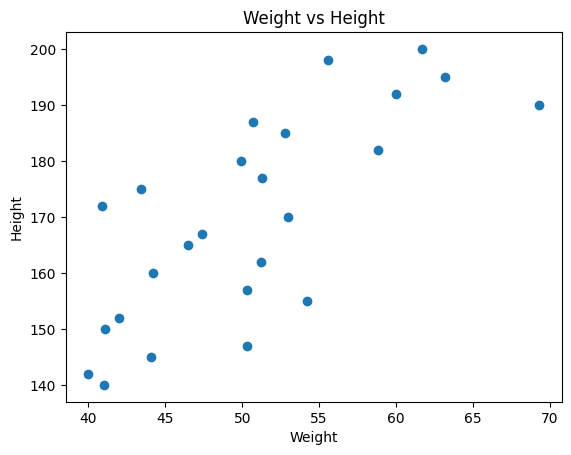

In [13]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Weight vs Height")
plt.show()

## Divide the Dataset into Independent and Dependent Features

We separate the dataset into:

- **X (Independent variable)** → Weight
- **y (Dependent variable)** → Height


In [14]:
X = df[['Weight']]   # Independent feature
y = df['Height']     # Dependent feature

## Train-Test Split

The dataset is divided into two parts:

- **Training Data** → Used to train the model
- **Testing Data** → Used to evaluate the model

Typically we use:

- 80% Training
- 20% Testing

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

Feature scaling standardizes the values so that the model trains efficiently.

Standardization Formula:

Z = (X − μ) / σ

Where:

- X = original value
- μ = mean
- σ = standard deviation

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train the Simple Linear Regression Model

The linear regression model learns the relationship between weight and height.

Regression Equation:

y = b₀ + b₁x

Where:

- y = predicted value
- x = input feature
- b₀ = intercept
- b₁ = slope


In [18]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

regressor.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Model Prediction

The trained model predicts height values for the test dataset.


In [19]:
y_pred = regressor.predict(X_test)


## Model Evaluation Metrics

Evaluation metrics measure how well the model predicts the target variable.

### Mean Absolute Error (MAE)

MAE measures the **average absolute difference between actual and predicted values**.

Formula

MAE = (1/n) Σ |yᵢ − ŷᵢ|

### Mean Squared Error (MSE)

MSE measures the **average squared difference between actual and predicted values**.

Formula

MSE = (1/n) Σ (yᵢ − ŷᵢ)²

### Root Mean Squared Error (RMSE)

RMSE is the **square root of MSE** and represents the error in the same unit as the target variable.

Formula

RMSE = √((1/n) Σ (yᵢ − ŷᵢ)²)


### R² Score (Coefficient of Determination)

R² measures how well the regression model explains the variance in the data.

Formula

R² = 1 − ( Σ(yᵢ − ŷᵢ)² / Σ(yᵢ − ȳ)² )


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Squared Error: 155.3870735497605
Mean Absolute Error: 10.226683514520374
Root Mean Squared Error: 12.465435152844062
R2 Score: 0.5884876230144054


## Regression Line Visualization

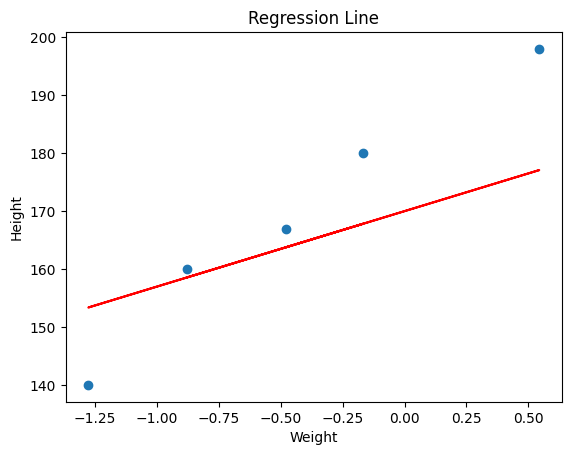

In [21]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Regression Line")
plt.show()

## Predicting New Data Points Using the Trained Model

After training the Linear Regression model, we can use it to predict the height for new weight values.

The model learns a linear relationship between weight and height.  
This relationship can be written as:

Predicted Height = Intercept + (Slope × Weight)

y = b₀ + (b₁ × x)

Where:

- **Predicted Height (y)** → The value predicted by the model.
- **Weight (x)** → The input feature used to make the prediction.
- **Intercept (b₀)** → The starting value of height when weight is zero.
- **Slope (b₁)** → The amount by which the height changes for every unit increase in weight.


### Model Parameters

The slope and intercept learned by the model can be obtained as follows:


In [22]:
print("Slope (Coefficient):", regressor.coef_)
print("Intercept:", regressor.intercept_)

Slope (Coefficient): [13.02343081]
Intercept: 170.0


### Predicting a New Data Point

We can use the trained model to predict the height for a new weight value.

In [23]:
# Example: Predict height for weight = 60
new_weight = np.array([[60]])

# Apply the same scaling used during training
scaled_weight = scaler.transform(new_weight)

# Predict height
predicted_height = regressor.predict(scaled_weight)

print("Predicted Height:", predicted_height)


Predicted Height: [184.23162272]


C:\Users\ANKIT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Predicting Multiple New Data Points

The model can also predict outputs for multiple input values at once.


In [24]:
# Predict heights for multiple weights
new_weights = np.array([[50], [60], [70]])

scaled_weights = scaler.transform(new_weights)

predicted_heights = regressor.predict(scaled_weights)

print("Predicted Heights:", predicted_heights)

Predicted Heights: [167.98547806 184.23162272 200.47776737]


C:\Users\ANKIT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Visualizing the Predicted Point

The predicted value can also be displayed on the regression graph.


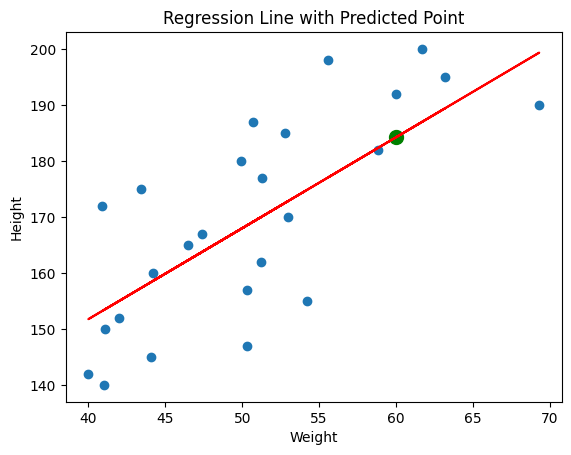

In [25]:
plt.scatter(df['Weight'], df['Height'])

plt.scatter(60, predicted_height, color='green', s=100)

plt.plot(
    df['Weight'],
    regressor.predict(scaler.transform(df[['Weight']])),
    color='red'
)

plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Regression Line with Predicted Point")

plt.show()